# ECG Data Pipeline & Exploration

St. Petersburg INCART 12-Lead Arrhythmia Database

This notebook loads the raw database files (.hea, .dat, .atr) into a single
partitioned Parquet dataset, then explores the data.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

SCRIPTS_DIR = Path.cwd() / 'scripts'
sys.path.insert(0, str(SCRIPTS_DIR if SCRIPTS_DIR.exists() else Path.cwd().parent / 'scripts'))
from loaders.incart.config import SIGNAL_PARTITION_DIR, ANNOTATION_PARTITION_DIR, DATA_DIR
from loaders.incart.build_dataframe import make_long

---
## 1. Build Dataset (if not already built)

In [2]:
import shutil
if SIGNAL_PARTITION_DIR.exists():
    shutil.rmtree(SIGNAL_PARTITION_DIR)
if ANNOTATION_PARTITION_DIR.exists():
    shutil.rmtree(ANNOTATION_PARTITION_DIR)
print("Building partitioned dataset from raw files...")
from loaders.incart.main import run
run()
print(f"  Signal partitions: {sum(f.stat().st_size for f in SIGNAL_PARTITION_DIR.rglob('*') if f.is_file()) / 1e6:.0f} MB")
print(f"  Annotation partitions: {sum(f.stat().st_size for f in ANNOTATION_PARTITION_DIR.rglob('*') if f.is_file()) / 1e6:.1f} MB")

Building partitioned dataset from raw files...
Building partitioned dataset from 75 ECG records...
[ 1/75] I01:
  Loaded header: 12 leads, 257 Hz, loading 417 / 462,600 samples
  Read binary signal: 11.1 MB, 417 × 12  (0.2s)
  Built wide DataFrame: 417 rows × 22 cols  (0.0s)
  Wrote signal parquet: 0.0 MB  (0.2s)
  Loaded annotations: 2,757 rows  (0.0s)
  Wrote annotation parquet: 0.03 MB  (0.0s)
  Done — 0.4s total
[ 2/75] I02:
  Loaded header: 12 leads, 257 Hz, loading 417 / 462,600 samples
  Read binary signal: 11.1 MB, 417 × 12  (0.2s)
  Built wide DataFrame: 417 rows × 22 cols  (0.0s)
  Wrote signal parquet: 0.0 MB  (0.0s)
  Loaded annotations: 2,674 rows  (0.0s)
  Wrote annotation parquet: 0.03 MB  (0.0s)
  Done — 0.2s total
[ 3/75] I03:
  Loaded header: 12 leads, 257 Hz, loading 417 / 462,600 samples
  Read binary signal: 11.1 MB, 417 × 12  (0.5s)
  Built wide DataFrame: 417 rows × 22 cols  (0.0s)
  Wrote signal parquet: 0.0 MB  (0.0s)
  Loaded annotations: 2,452 rows  (0.0s)
  

---
## 2. Dataset Overview

In [3]:
record_ids = [f"I{i:02d}" for i in range(1, 76)]

sample = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id=I01/part-00000.parquet")
n_samples_per_record = sample.shape[0]
n_total_rows = 0
for rid in record_ids:
    n_total_rows += pd.read_parquet(
        f"{SIGNAL_PARTITION_DIR}/record_id={rid}/part-00000.parquet"
    ).shape[0]

print(f"Records: {len(record_ids)}")
print(f"Total samples: {n_total_rows:,}")
print(f"Samples per record: {n_samples_per_record:,}")
print(f"Leads per record: 12")
print(f"Sampling rate: 257 Hz")
print(f"Duration per record: {n_samples_per_record / 257:.1f} s")
print(f"Columns in signal DataFrame: {sample.columns.tolist()}")

Records: 75
Total samples: 31,275
Samples per record: 417
Leads per record: 12
Sampling rate: 257 Hz
Duration per record: 1.6 s
Columns in signal DataFrame: ['sample_index', 'time', 'I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'patient_id', 'age', 'sex', 'diagnoses', 'description', 'fs', 'gain']


In [ ]:
# Patient demographics
patients = {}
for rid in record_ids:
    df = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id={rid}/part-00000.parquet")
    pid = int(df["patient_id"].iloc[0])
    if pid not in patients:
        patients[pid] = {
            "records": [], "age": df["age"].iloc[0],
            "sex": df["sex"].iloc[0], "diagnoses": df["diagnoses"].iloc[0]
        }
    patients[pid]["records"].append(rid)

ages = [p["age"] for p in patients.values() if p["age"] is not None]
sexes = [p["sex"] for p in patients.values() if p["sex"] is not None]

print(f"Unique patients: {len(patients)}")
print(f"Age range: {min(ages)}-{max(ages)} (mean {np.mean(ages):.0f})")
print(f"Sex: {sexes.count('M')} M, {sexes.count('F')} F")
print()

diag_counts = {}
for p in patients.values():
    d = p["diagnoses"] if p["diagnoses"] and p["diagnoses"] != "nan" else "unspecified"
    diag_counts[d] = diag_counts.get(d, 0) + 1

print("Diagnoses distribution:")
for d, c in sorted(diag_counts.items(), key=lambda x: -x[1]):
    print(f"  {d}: {c} patients")

Unique patients: 32
Age range: 38–80 (mean 61)
Sex: 10 M, 8 F

Diagnoses distribution:
  unspecified: 14 patients
  Transient ischemic attack: 4 patients
  Coronary artery disease, arterial hypertension, left ventricular hypertrophy: 4 patients
  Earlier MI: 4 patients
  Coronary artery disease, arterial hypertension: 3 patients
  Acute MI: 2 patients
  Sinus node dysfunction: 1 patients


---
## 3. Signal Exploration

In [5]:
# Per-lead stats for a sample record
df = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id=I01/part-00000.parquet")
long_df = make_long(df)
print("I01 per-lead voltage stats (mV):")
display(long_df.groupby("lead", observed=True)["voltage_mV"].agg(["min", "max", "mean", "std"]).round(3))

I01 per-lead voltage stats (mV):


,min,max,mean,std
lead,,,,
AVF,-0.245,1.408,0.612,0.242
AVL,1.072,2.199,1.464,0.154
AVR,-3.631,-2.232,-2.742,0.183
I,3.444,4.810,3.727,0.158
II,0.575,2.288,1.486,0.267
III,-1.059,0.546,-0.244,0.241
V1,-4.065,-3.222,-3.552,0.125
V2,-3.866,-2.663,-3.498,0.181
V3,-4.275,-2.451,-3.717,0.272


In [6]:
# High-frequency noise per lead (std of successive differences)
print("I01 high-frequency noise (std of diff) per lead (mV):")
hf = long_df.groupby("lead", observed=True)["voltage_mV"].diff().groupby(long_df["lead"]).std()
display(hf.round(4).to_frame("hf_noise_mV"))

I01 high-frequency noise (std of diff) per lead (mV):


,hf_noise_mV
lead,
AVF,0.0544
AVL,0.0514
AVR,0.0550
I,0.0612
II,0.0644
III,0.0602
V1,0.0411
V2,0.0446
V3,0.0628


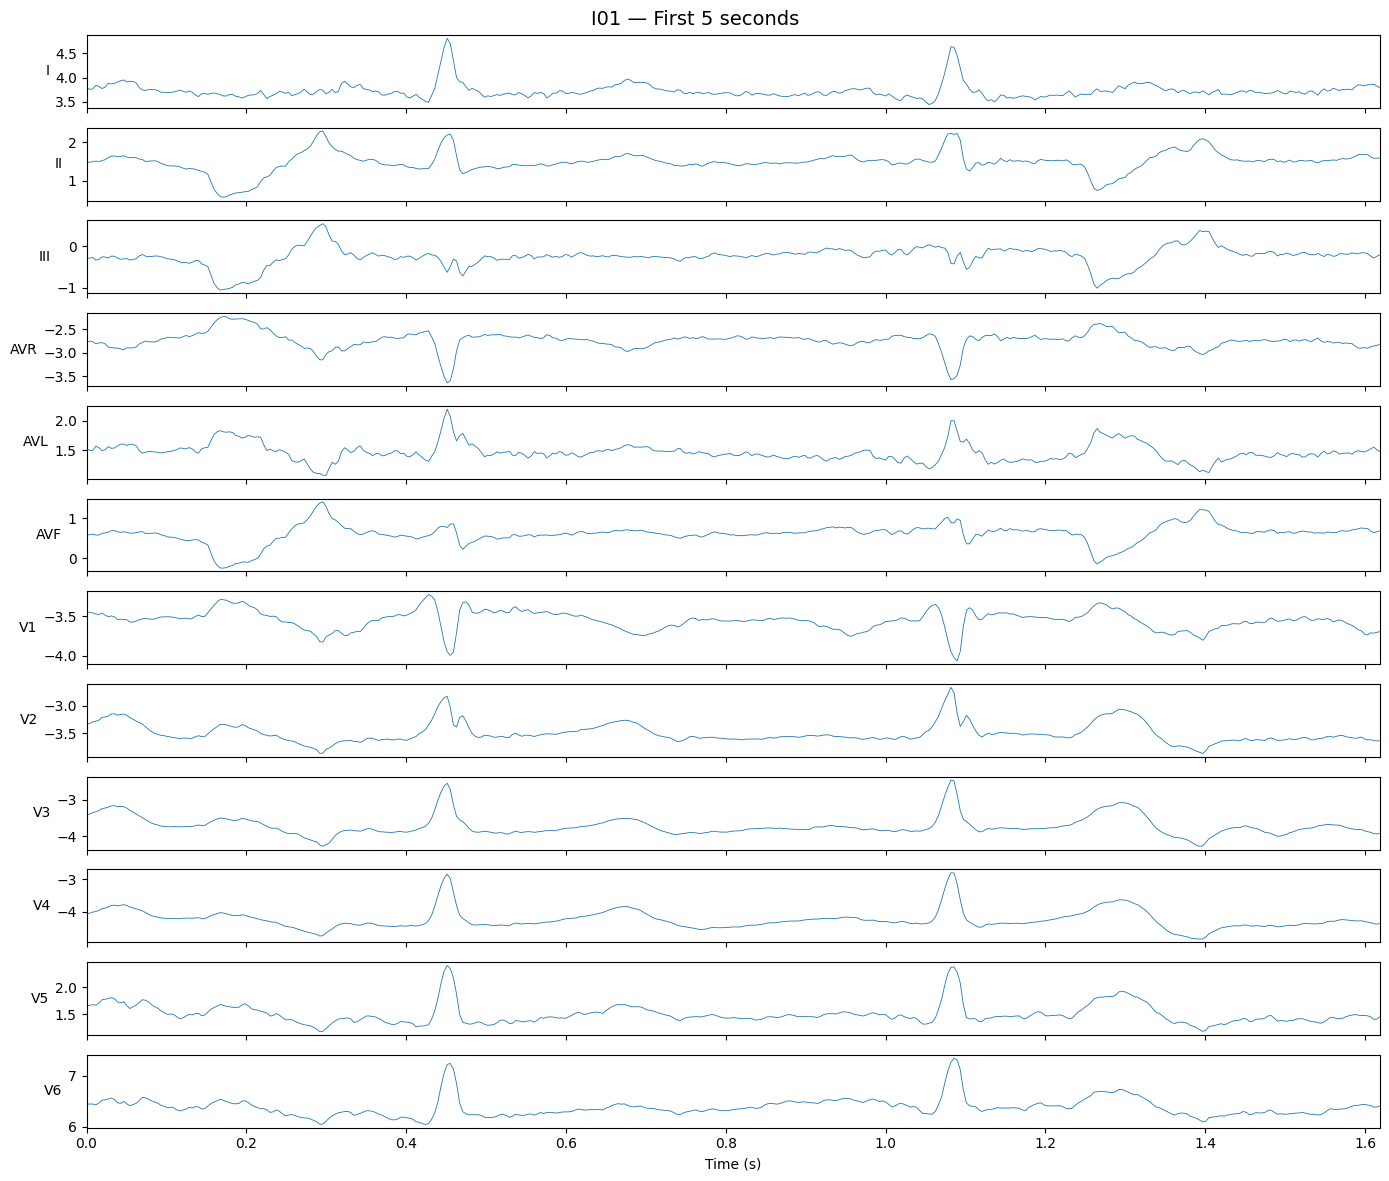

In [7]:
# Plot first 5 seconds of all 12 leads for I01
import matplotlib.pyplot as plt

df = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id=I01/part-00000.parquet")
long_df = make_long(df)
leads = ["I", "II", "III", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]
fig, axes = plt.subplots(12, 1, figsize=(14, 12), sharex=True)
for ax, lead in zip(axes, leads):
    seg = long_df[long_df["lead"] == lead]
    mask = seg["time"] <= 5
    ax.plot(seg.loc[mask, "time"], seg.loc[mask, "voltage_mV"], linewidth=0.6)
    ax.set_ylabel(lead, rotation=0, ha="right", va="center")
    ax.margins(x=0)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("I01 — First 5 seconds", fontsize=14)
plt.tight_layout()
plt.show()

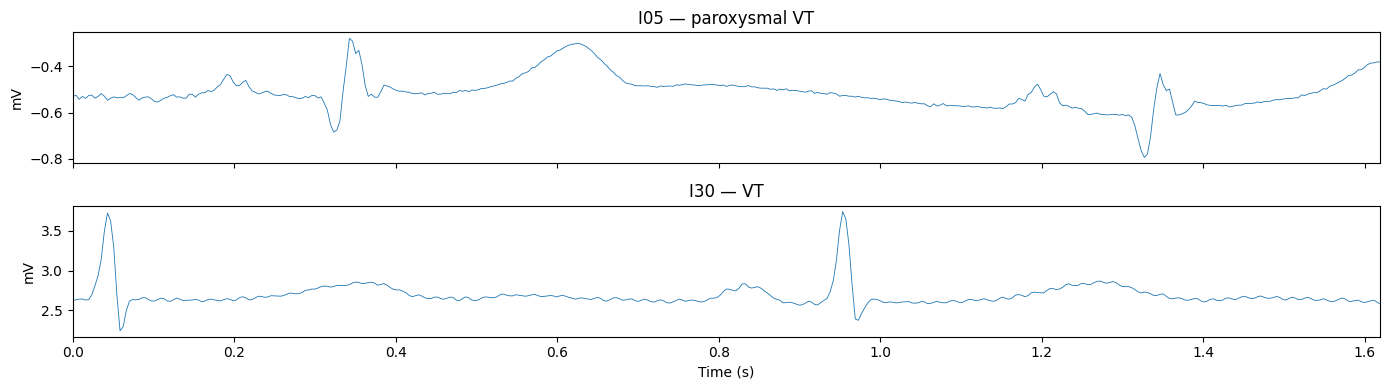

In [8]:
# Compare two records with different pathologies
rid_a, rid_b = "I05", "I30"

df_a = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id={rid_a}/part-00000.parquet")
df_b = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id={rid_b}/part-00000.parquet")
long_a, long_b = make_long(df_a), make_long(df_b)

fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
for ax, (rid, sig) in zip(axes, [(rid_a, long_a), (rid_b, long_b)]):
    lead_ii = sig[sig["lead"] == "II"]
    mask = lead_ii["time"] <= 10
    desc = lead_ii["description"].iloc[0]
    ax.plot(lead_ii.loc[mask, "time"], lead_ii.loc[mask, "voltage_mV"], linewidth=0.6)
    ax.set_title(f"{rid} — {desc}")
    ax.set_ylabel("mV")
    ax.margins(x=0)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

---
## 4. Annotation Analysis

In [9]:
total_beats = 0
symbol_counts = {}
for rid in record_ids:
    ann = pd.read_parquet(f"{ANNOTATION_PARTITION_DIR}/record_id={rid}/part-00000.parquet")
    total_beats += ann.shape[0]
    for sym in ann["symbol"]:
        symbol_counts[sym] = symbol_counts.get(sym, 0) + 1

print(f"Total annotations: {total_beats:,}")
print(f"Unique beat types: {len(symbol_counts)}")
print()

beat_df = pd.DataFrame({
    "symbol": list(symbol_counts.keys()),
    "count": list(symbol_counts.values()),
}).sort_values("count", ascending=False)
beat_df["pct"] = (beat_df["count"] / total_beats * 100).round(1)
print("Beat type distribution:")
display(beat_df)

Total annotations: 175,919
Unique beat types: 11

Beat type distribution:


,symbol,count,pct
0,N,150410,85.5
1,V,20013,11.4
6,R,3174,1.8
2,A,1944,1.1
3,F,219,0.1
10,j,92,0.1
5,n,32,0.0
8,S,16,0.0
9,+,12,0.0
4,Q,6,0.0


In [ ]:
# Heart rate per patient
patient_hr = {}
for rid in record_ids:
    ann = pd.read_parquet(f"{ANNOTATION_PARTITION_DIR}/record_id={rid}/part-00000.parquet")
    if ann.shape[0] < 2:
        continue
    duration = ann["time"].iloc[-1] - ann["time"].iloc[0]
    hr = ann.shape[0] / (duration / 60) if duration > 0 else 0
    sig = pd.read_parquet(f"{SIGNAL_PARTITION_DIR}/record_id={rid}/part-00000.parquet")
    pid = int(sig["patient_id"].iloc[0])
    patient_hr.setdefault(pid, []).append(hr)

hr_df = pd.DataFrame([
    {"patient": pid, "mean_hr": np.mean(hrs), "records": len(hrs),
     "min_hr": min(hrs), "max_hr": max(hrs)}
    for pid, hrs in sorted(patient_hr.items())
])
print("Heart rate per patient:")
display(hr_df.style.format({"mean_hr": "{:.0f}", "min_hr": "{:.0f}", "max_hr": "{:.0f}"}))
print(f"Global heart rate range: {hr_df['mean_hr'].min():.0f}-{hr_df['mean_hr'].max():.0f} bpm")

Heart rate per patient:


,patient,mean_hr,records,min_hr,max_hr
0,1,91,2,89,92
1,2,74,3,59,82
2,3,87,2,83,90
3,4,71,1,71,71
4,5,98,3,70,123
5,6,74,3,62,94
6,7,88,1,88,88
7,8,53,2,51,56
8,9,86,2,69,103
9,10,89,3,73,104


Global heart rate range: 53–112 bpm


---
## 5. Query Examples

In [11]:
# Load multiple records at once via filters
sig_subset = pd.read_parquet(
    str(SIGNAL_PARTITION_DIR),
    filters=[("record_id", "in", ["I01", "I02", "I03"])]
)
print(f"Loaded 3 records: {sig_subset.shape[0]:,} rows")
print(f"Unique records: {sig_subset['record_id'].unique().tolist()}")

Loaded 3 records: 1,251 rows
Unique records: ['I01', 'I02', 'I03']


In [12]:
# Merge annotations onto signals for analysis
ann_subset = pd.read_parquet(
    str(ANNOTATION_PARTITION_DIR),
    filters=[("record_id", "=", "I01")]
)
sig_i01 = pd.read_parquet(
    str(SIGNAL_PARTITION_DIR),
    filters=[("record_id", "=", "I01")]
)
sig_i01_long = make_long(sig_i01)

merged = pd.merge_asof(
    sig_i01_long[["sample_index", "time", "lead", "voltage_mV"]].sort_values("sample_index"),
    ann_subset[["sample_index", "symbol", "description"]].sort_values("sample_index"),
    on="sample_index",
)
print(f"Merged shape: {merged.shape}")
print(merged.head(10))

Merged shape: (5004, 6)
   sample_index  time lead  voltage_mV symbol description
0             0   0.0  AVF    0.584967    NaN         NaN
1             0   0.0  AVL    1.526144    NaN         NaN
2             0   0.0  AVR   -2.777778    NaN         NaN
3             0   0.0    I    3.794118    NaN         NaN
4             0   0.0   II    1.493464    NaN         NaN
5             0   0.0  III   -0.303922    NaN         NaN
6             0   0.0   V1   -3.437908    NaN         NaN
7             0   0.0   V2   -3.333333    NaN         NaN
8             0   0.0   V3   -3.415033    NaN         NaN
9             0   0.0   V4   -4.071896    NaN         NaN


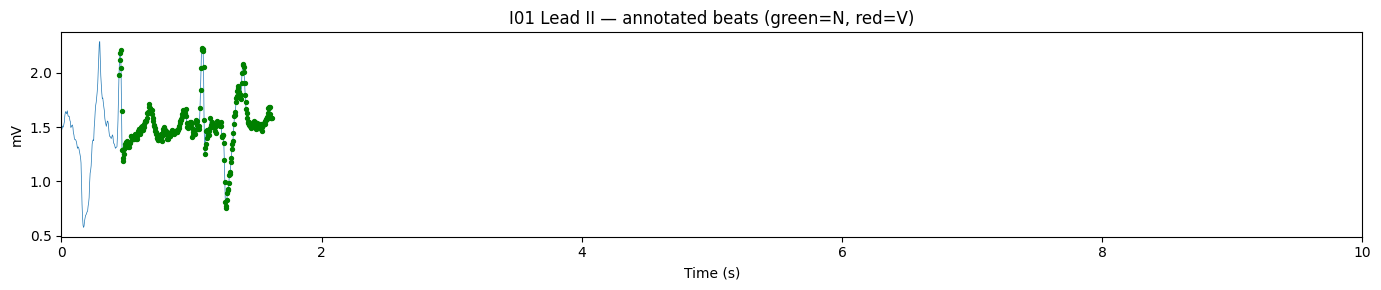

In [13]:
# Mark annotated beats on a lead II trace
lead_ii = merged[merged["lead"] == "II"].copy()
lead_ii["is_beat"] = lead_ii["symbol"].notna()
beats = lead_ii[lead_ii["is_beat"]]

fig, ax = plt.subplots(figsize=(14, 3))
t = lead_ii["time"]
v = lead_ii["voltage_mV"]
ax.plot(t, v, linewidth=0.5, label="Lead II")
beat_times = beats["time"].values
beat_v = beats["voltage_mV"].values
colors = {"N": "green", "V": "red", "A": "orange"}
for bt, bv, sym in zip(beats["time"], beats["voltage_mV"], beats["symbol"]):
    c = colors.get(sym, "gray")
    ax.scatter(bt, bv, color=c, s=8, zorder=5)
ax.set_xlim(0, 10)
ax.set_xlabel("Time (s)")
ax.set_ylabel("mV")
ax.set_title("I01 Lead II — annotated beats (green=N, red=V)")
plt.tight_layout()
plt.show()